# Heart Failure Prediction Project
Cleaned and fixed version with SVM and ANN models.

In [1]:

!pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


## Load Dataset

In [3]:

dataset = pd.read_csv("heart_failure_clinical_records_dataset.csv")

dataset.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:

dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [5]:

dataset.describe()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## Correlation Heatmap

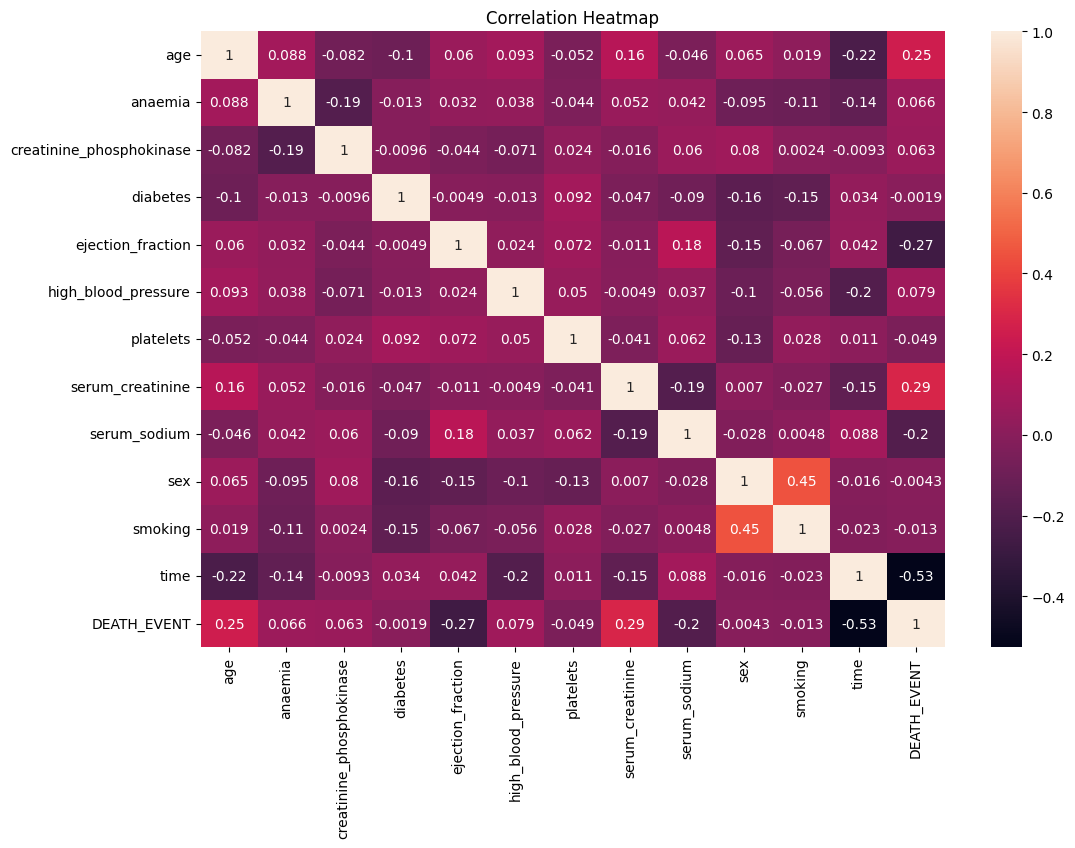

In [6]:

plt.figure(figsize=(12, 8))

sns.heatmap(dataset.corr(numeric_only=True), annot=True)

plt.title("Correlation Heatmap")

plt.show()


## Feature Selection

In [7]:

X = dataset.drop("DEATH_EVENT", axis=1)
y = dataset["DEATH_EVENT"]


## Train Test Split

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)


## Scaling

In [9]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## SVM Model

In [10]:

svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))


SVM Accuracy: 0.7666666666666667


In [11]:

print(classification_report(y_test, svm_pred))


              precision    recall  f1-score   support

           0       0.74      0.92      0.82        53
           1       0.83      0.54      0.66        37

    accuracy                           0.77        90
   macro avg       0.79      0.73      0.74        90
weighted avg       0.78      0.77      0.75        90



## ANN Model

In [12]:

ann_model = Sequential()

ann_model.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
ann_model.add(Dense(8, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:

history = ann_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    verbose=1
)


Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3636 - loss: 0.7802 - val_accuracy: 0.4000 - val_loss: 0.7821
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4450 - loss: 0.7341 - val_accuracy: 0.4333 - val_loss: 0.7612
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5120 - loss: 0.7028 - val_accuracy: 0.4556 - val_loss: 0.7456
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5742 - loss: 0.6765 - val_accuracy: 0.4778 - val_loss: 0.7335
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6077 - loss: 0.6509 - val_accuracy: 0.5222 - val_loss: 0.7211
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6699 - loss: 0.6279 - val_accuracy: 0.5889 - val_loss: 0.7093
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6986 - loss: 0.6034 - val_accuracy: 0.6444 - val_loss: 0.6971
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7225 - loss: 0.5782 - val_accuracy: 0.6444 - val_loss

## ANN Evaluation

In [14]:

ann_pred = ann_model.predict(X_test)

ann_pred = (ann_pred > 0.5).astype(int)

print("ANN Accuracy:", accuracy_score(y_test, ann_pred))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
ANN Accuracy: 0.7666666666666667


In [15]:

print(classification_report(y_test, ann_pred))


              precision    recall  f1-score   support

           0       0.74      0.92      0.82        53
           1       0.83      0.54      0.66        37

    accuracy                           0.77        90
   macro avg       0.79      0.73      0.74        90
weighted avg       0.78      0.77      0.75        90



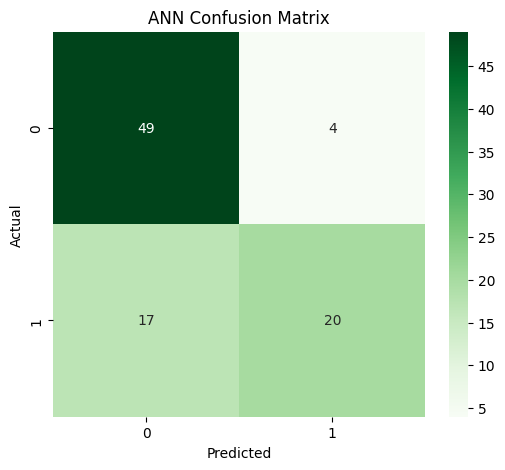

In [16]:

cm = confusion_matrix(y_test, ann_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ANN Confusion Matrix")

plt.show()


## Training vs Validation Loss

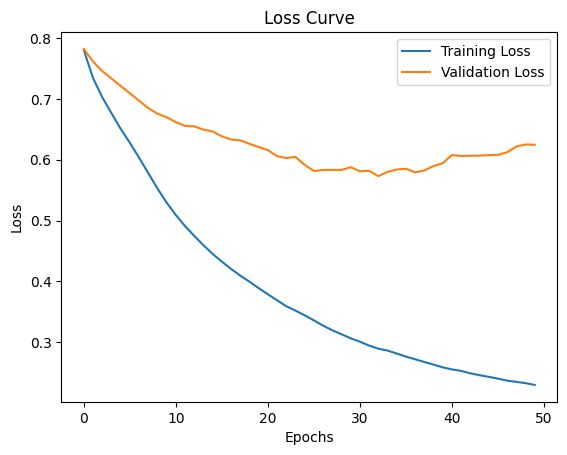

In [17]:

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.show()
